# Notebook 17 — BKZ and scaling

LLL is fast but weak. BKZ (Block Korkine–Zolotarev) trades time for quality by doing SVP inside small blocks. We implement it, measure the quality/cost tradeoff, and see where pure-Python runs out of steam.

In [1]:
import numpy as np, time
import matplotlib.pyplot as plt
from pqc_edu.attacks_advanced.lll import lll_reduce
from pqc_edu.attacks_advanced.bkz import bkz_reduce, svp_enumerate

## The BKZ loop

In each "tour" over the basis:

1. LLL-reduce the whole basis.
2. For each block of $\beta$ consecutive vectors, find the exact shortest vector in the sublattice (via enumeration).
3. Insert that short vector into the block; LLL again.

Larger $\beta$ means better reduction — but enumeration is exponential in $\beta$, so cost explodes. In production, $\beta$ goes up to 50–90 (via fpylll). Our pure-Python enumeration handles $\beta \le 6$ comfortably.

block_size=2   ||b_1||=   45.77   time= 0.01s
block_size=3   ||b_1||=   45.77   time= 0.02s
block_size=4   ||b_1||=   45.77   time= 0.09s


block_size=5   ||b_1||=   45.77   time= 0.41s


block_size=6   ||b_1||=   45.77   time= 1.88s


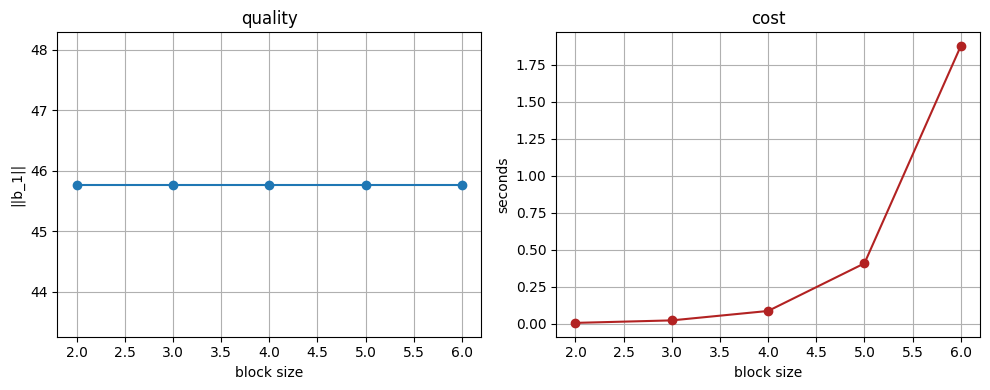

In [2]:
rng = np.random.default_rng(0)
B_seed = rng.integers(-40, 40, (8, 8)).astype(np.int64)
while abs(np.linalg.det(B_seed)) < 1.0:
    B_seed = rng.integers(-40, 40, (8, 8)).astype(np.int64)

blocks = [2, 3, 4, 5, 6]
lengths = []
times = []
for bs in blocks:
    t0 = time.time()
    R = bkz_reduce(B_seed.copy(), block_size=bs)
    times.append(time.time() - t0)
    lengths.append(float(np.linalg.norm(R[0])))
    print(f'block_size={bs}   ||b_1||={lengths[-1]:8.2f}   time={times[-1]:5.2f}s')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(blocks, lengths, 'o-'); axes[0].set_xlabel('block size'); axes[0].set_ylabel('||b_1||'); axes[0].set_title('quality')
axes[1].plot(blocks, times, 'o-', color='firebrick'); axes[1].set_xlabel('block size'); axes[1].set_ylabel('seconds'); axes[1].set_title('cost')
for ax in axes: ax.grid(True)
plt.tight_layout(); plt.show()

## Why this matters for attacking LWE

LWE secrets (s, e) correspond to a short vector in the "primal lattice" we build next notebook. If BKZ can recover a sufficiently short vector, the secret falls out. The block size you need grows with the LWE dimension — this is the core of cost estimation for ML-KEM's parameter choice.

## Enumeration: inside the block

Inside each block, we search for the shortest nonzero integer combination of the block's basis vectors. Our `svp_enumerate` uses iterative deepening over coefficient ranges [-c, c]. Schnorr-Euchner enumeration (with pruning by GSO norms) would be faster but harder to read; both find the same vector.

In [3]:
B_small = np.array([[3, 1, 0], [1, 3, 1], [0, 1, 3]], dtype=np.int64)
v = svp_enumerate(B_small)
print('shortest vector:', v)
print('norm^2:', int(np.dot(v, v)))

shortest vector: [-2  1 -2]
norm^2: 9


## Takeaway

- BKZ-$\beta$ quality improves as $\beta$ grows; our pure-Python caps around $\beta = 6$.
- Real attacks use $\beta = 40$–$80$+ via fpylll. The Python/Rust/C++ implementation gap is ~3 orders of magnitude.
- ML-KEM parameters are chosen so the **best known BKZ attack** costs $2^{140}$+ operations — see notebook 19.

→ `18_primal_attack_on_lwe.ipynb`